# Portfolio Assessment 3
Part - A

IMPORT LIBRARIES

In [27]:
# Core libraries for numerical operations and data manipulation
import numpy as np # For numerical operations
import pandas as pd # For data manipulation and analysis

# Libraries for plotting and visualization
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # For making statistical graphics based on matplotlib

# Libraries for saving and loading models
import joblib # For saving and loading scikit-learn models
import pickle # For serializing and deserializing Python objects

# Scikit-learn modules for model selection, preprocessing, and ensemble methods
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold # For splitting data, cross-validation
from sklearn.preprocessing import StandardScaler, MinMaxScaler # For feature scaling
from sklearn.impute import SimpleImputer # For handling missing values
from sklearn.ensemble import RandomForestClassifier # Random Forest classification algorithm
from sklearn.neural_network import MLPClassifier # Multi-layer Perceptron classification algorithm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix # For evaluating model performance

# TensorFlow and Keras for deep learning models, specifically LSTMs
import tensorflow as tf # Deep learning framework
from tensorflow.keras.models import Sequential # For building sequential neural networks
from tensorflow.keras.layers import LSTM, Dense, Dropout # LSTM layer, dense layer, and dropout layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Callbacks for early stopping and learning rate reduction

# Set the aesthetic style of the plots
sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


LOAD DATASET

In [28]:
# Mount Google Drive to access files stored in Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the file path to the dataset. Change this if your file is in a different folder
file_path = "/content/drive/MyDrive/cleaned_ur3_cobotops.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape) # Print the number of rows and columns
display(df.head()) # Display the first 5 rows of the DataFrame

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Shape: (6546, 28)


,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost,Hour,Day,Month,grip_lost_numeric
0,1,2022-10-26 08:17:21.847000+00:00,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,-0.007479,-0.152962,0.082732,1,0.0,False,8,26,10,0
1,2,2022-10-26 08:17:22.852000+00:00,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-0.000767,0.000417,0.505895,1,0.0,False,8,26,10,0
2,3,2022-10-26 08:17:23.857000+00:00,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,0.000455,-0.496856,0.079420,1,0.0,False,8,26,10,0
3,4,2022-10-26 08:17:24.863000+00:00,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,0.018411,0.425559,0.083325,1,0.0,False,8,26,10,0
4,5,2022-10-26 08:17:25.877000+00:00,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,0.014994,0.180989,0.086379,1,0.0,False,8,26,10,0


INSPECT DATASET


In [29]:
print("Column names:")
print(df.columns.tolist()) # Print a list of all column names in the DataFrame

print("\nData types:")
display(df.dtypes) # Display the data types of each column

print("\nMissing values:")
display(df.isnull().sum()) # Display the count of missing values for each column

print("\nTarget distribution:")
# Print the value counts for the original and numeric target columns
print(df["grip_lost"].value_counts())
print(df["grip_lost_numeric"].value_counts())

Column names:
['Num', 'Timestamp', 'Current_J0', 'Temperature_T0', 'Current_J1', 'Temperature_J1', 'Current_J2', 'Temperature_J2', 'Current_J3', 'Temperature_J3', 'Current_J4', 'Temperature_J4', 'Current_J5', 'Temperature_J5', 'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5', 'Tool_current', 'cycle', 'Robot_ProtectiveStop', 'grip_lost', 'Hour', 'Day', 'Month', 'grip_lost_numeric']

Data types:


,0
Num,int64
Timestamp,object
Current_J0,float64
Temperature_T0,float64
Current_J1,float64
Temperature_J1,float64
Current_J2,float64
Temperature_J2,float64
Current_J3,float64
Temperature_J3,float64



Missing values:


,0
Num,0
Timestamp,0
Current_J0,46
Temperature_T0,46
Current_J1,46
Temperature_J1,46
Current_J2,46
Temperature_J2,46
Current_J3,46
Temperature_J3,46



Target distribution:
grip_lost
False    6334
True      212
Name: count, dtype: int64
grip_lost_numeric
0    6334
1     212
Name: count, dtype: int64


PREPARE FEATURES AND TARGET

In [30]:
# Define columns to be dropped from the feature set
# "grip_lost" is the original target, "grip_lost_numeric" is the numeric target
# "Timestamp" and "Num" are identifiers not used for prediction
drop_cols = ["grip_lost", "grip_lost_numeric", "Timestamp", "Num"]

# Create feature matrix X by dropping specified columns. `errors="ignore"` prevents error if column not found.
X = df.drop(columns=drop_cols, errors="ignore")
# Create target vector y using the numeric target column
y = df["grip_lost_numeric"]

print("Feature shape:", X.shape) # Print the shape of the feature matrix
print("Target shape:", y.shape) # Print the shape of the target vector
display(X.head()) # Display the first 5 rows of the feature matrix

Feature shape: (6546, 24)
Target shape: (6546,)


,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,Hour,Day,Month
0,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,8,26,10
1,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,8,26,10
2,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,8,26,10
3,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,8,26,10
4,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,8,26,10


IMPUTE AND SPLIT DATA

In [31]:

# Initialize SimpleImputer to fill missing values using the mean strategy
imputer = SimpleImputer(strategy="mean")
# Fit the imputer on X and transform it, then convert back to DataFrame with original columns
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split the data into training and testing sets
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state for reproducibility
# stratify=y ensures that both train and test sets have similar proportions of target classes
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape) # Print the shape of the training features
print("Testing set shape:", X_test.shape) # Print the shape of the testing features

Training set shape: (5236, 24)
Testing set shape: (1310, 24)


SCALE FEATURES

In [32]:
# Initialize StandardScaler for standardizing features (mean=0, variance=1)
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Scaled train shape:", X_train_scaled.shape) # Print shape of scaled training features
print("Scaled test shape:", X_test_scaled.shape) # Print shape of scaled testing features

Scaling completed.
Scaled train shape: (5236, 24)
Scaled test shape: (1310, 24)


RANDOM FOREST CLASSIFIER

In [33]:
# Initialize a RandomForestClassifier model
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# class_weight="balanced": handles imbalanced datasets by adjusting weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the Random Forest model using the scaled training data
rf_model.fit(X_train_scaled, y_train)
# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate evaluation metrics
rf_acc = accuracy_score(y_test, y_pred_rf) # Accuracy score
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted") # Weighted F1-score to account for class imbalance

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Weighted F1:", rf_f1)
print("\nClassification Report:\n")
# Print a detailed classification report including precision, recall, f1-score for each class
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.9770992366412213
Random Forest Weighted F1: 0.9720825090788714

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1268
           1       0.88      0.33      0.48        42

    accuracy                           0.98      1310
   macro avg       0.93      0.67      0.74      1310
weighted avg       0.98      0.98      0.97      1310



MLP CLASSIFIER

In [34]:
# Initialize an MLPClassifier model (Multi-layer Perceptron)
# hidden_layer_sizes: defines the architecture of the hidden layers (e.g., two layers with 64 and 32 neurons)
# activation: activation function for the hidden layers
# max_iter: maximum number of iterations for the solver to converge
# random_state: for reproducibility
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=300,
    random_state=42
)

# Train the MLP model using the scaled training data
mlp_model.fit(X_train_scaled, y_train)
# Make predictions on the scaled test data
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Calculate evaluation metrics
mlp_acc = accuracy_score(y_test, y_pred_mlp) # Accuracy score
mlp_f1 = f1_score(y_test, y_pred_mlp, average="weighted") # Weighted F1-score

print("MLP Accuracy:", mlp_acc)
print("MLP Weighted F1:", mlp_f1)
print("\nClassification Report:\n")
# Print a detailed classification report
print(classification_report(y_test, y_pred_mlp, zero_division=0))

MLP Accuracy: 0.9732824427480916
MLP Weighted F1: 0.9689392288394578

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1268
           1       0.67      0.33      0.44        42

    accuracy                           0.97      1310
   macro avg       0.82      0.66      0.72      1310
weighted avg       0.97      0.97      0.97      1310



CROSS-VALIDATION

In [35]:

# Initialize StratifiedKFold for cross-validation
# n_splits: number of folds (e.g., 5-fold cross-validation)
# shuffle: whether to shuffle the data before splitting
# random_state: for reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for Random Forest model
# X_imputed and y are used here to perform CV on the full dataset before splitting to train/test
# scoring="accuracy": metric to evaluate model performance
rf_cv = cross_val_score(rf_model, X_imputed, y, cv=cv, scoring="accuracy")

# Perform cross-validation for MLP Classifier model
mlp_cv = cross_val_score(mlp_model, X_imputed, y, cv=cv, scoring="accuracy")

print("Random Forest CV Accuracy:", rf_cv.mean()) # Print the average CV accuracy for Random Forest
print("MLP CV Accuracy:", mlp_cv.mean()) # Print the average CV accuracy for MLP

Random Forest CV Accuracy: 0.9758630502860409
MLP CV Accuracy: 0.9676138769178733


PART A RESULTS TABLE

In [36]:

# Create a pandas DataFrame to summarize the results of traditional ML models
traditional_results = pd.DataFrame({
    "Model": ["Random Forest", "MLP Classifier"], # Model names
    "Accuracy": [rf_acc, mlp_acc], # Test accuracy scores
    "Weighted F1 Score": [rf_f1, mlp_f1], # Test weighted F1 scores
    "5-Fold CV Accuracy": [rf_cv.mean(), mlp_cv.mean()] # Average 5-fold cross-validation accuracy
})

display(traditional_results) # Display the results table

,Model,Accuracy,Weighted F1 Score,5-Fold CV Accuracy
0,Random Forest,0.977099,0.972083,0.975863
1,MLP Classifier,0.973282,0.968939,0.967614


 PART A BAR CHART

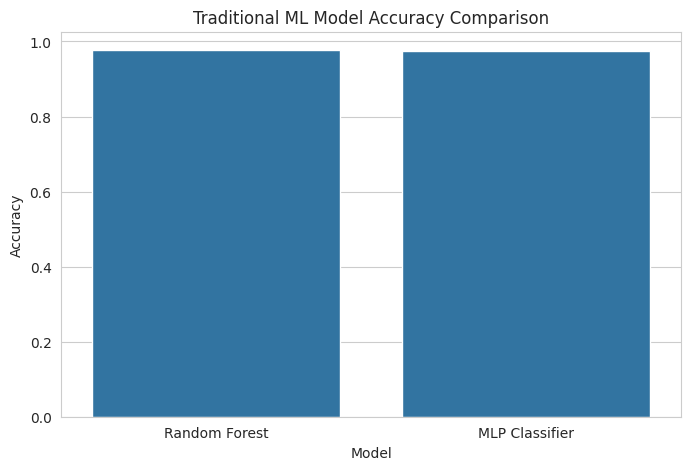

In [37]:
plt.figure(figsize=(8, 5)) # Set the figure size for the plot
# Create a bar plot comparing the accuracy of traditional ML models
sns.barplot(data=traditional_results, x="Model", y="Accuracy")
plt.title("Traditional ML Model Accuracy Comparison") # Set the title of the plot
plt.xlabel("Model") # Set the x-axis label
plt.ylabel("Accuracy") # Set the y-axis label
plt.show() # Display the plot

# Portfolio Assessment 3

Part - B

 PREPARE DATA FOR LSTM

In [38]:
# Create a copy of the original DataFrame for sequence modeling
df_seq = df.copy()
# Convert the 'Timestamp' column to datetime objects with ISO8601 format specification
df_seq["Timestamp"] = pd.to_datetime(df_seq["Timestamp"], format='ISO8601')
# Sort the DataFrame by 'Timestamp' to preserve sequence order, then reset index
df_seq = df_seq.sort_values("Timestamp").reset_index(drop=True)

# Select numeric feature columns for sequence modeling
# Exclude target columns and identifier columns
feature_cols = [col for col in df_seq.columns if col not in ["grip_lost", "grip_lost_numeric", "Timestamp", "Num"]]

X_seq_raw = df_seq[feature_cols] # Raw sequential features
y_seq_raw = df_seq["grip_lost_numeric"] # Raw sequential target

print("Sequential feature shape:", X_seq_raw.shape) # Print shape of sequential features
print("Sequential target shape:", y_seq_raw.shape) # Print shape of sequential target

Sequential feature shape: (6546, 24)
Sequential target shape: (6546,)


MINMAX SCALE FOR LSTM

In [39]:
# Initialize SimpleImputer for sequential data to fill missing values using the mean
seq_imputer = SimpleImputer(strategy="mean")
# Impute missing values and convert back to DataFrame
X_seq_imputed = pd.DataFrame(seq_imputer.fit_transform(X_seq_raw), columns=feature_cols)

# Initialize MinMaxScaler for scaling features to a range [0, 1]
seq_scaler = MinMaxScaler()
# Fit the scaler on the imputed sequential data and transform it
X_seq_scaled = seq_scaler.fit_transform(X_seq_imputed)

print("LSTM scaling completed.")
print("Scaled sequential data shape:", X_seq_scaled.shape) # Print shape of scaled sequential data

LSTM scaling completed.
Scaled sequential data shape: (6546, 24)


CREATE SEQUENCES

In [40]:
# Define the length of each sequence (e.g., 20 time steps)
sequence_length = 20

# Function to create sequences for LSTM from time-series data
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    # Iterate through the data to create overlapping sequences
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len]) # Features for the current sequence
        ys.append(y.iloc[i+seq_len]) # Target for the next time step after the sequence
    return np.array(Xs), np.array(ys) # Return sequences as numpy arrays

# Create LSTM input sequences and corresponding targets
X_lstm, y_lstm = create_sequences(X_seq_scaled, y_seq_raw, sequence_length)

print("LSTM input shape:", X_lstm.shape) # Print the shape of LSTM input (samples, time_steps, features)
print("LSTM target shape:", y_lstm.shape) # Print the shape of LSTM target

LSTM input shape: (6526, 20, 24)
LSTM target shape: (6526,)


 SPLIT SEQUENCE DATA

In [41]:
# Split the sequence data into training, validation, and testing sets
# A temporal split is used instead of random shuffle to maintain the time-series order.

# Calculate the size for training set (70% of total sequences)
train_size = int(len(X_lstm) * 0.7)
# Calculate the size for validation set (15% of total sequences)
val_size = int(len(X_lstm) * 0.15)

# Assign data to training set
X_train_lstm = X_lstm[:train_size]
y_train_lstm = y_lstm[:train_size]

# Assign data to validation set
X_val_lstm = X_lstm[train_size:train_size + val_size]
y_val_lstm = y_lstm[train_size:train_size + val_size]

# Assign remaining data to testing set
X_test_lstm = X_lstm[train_size + val_size:]
y_test_lstm = y_lstm[train_size + val_size:]

print("Train shape:", X_train_lstm.shape) # Print shape of LSTM training features
print("Validation shape:", X_val_lstm.shape) # Print shape of LSTM validation features
print("Test shape:", X_test_lstm.shape) # Print shape of LSTM testing features

Train shape: (4568, 20, 24)
Validation shape: (978, 20, 24)
Test shape: (980, 20, 24)


BUILD LSTM MODEL

In [42]:
# Build a Sequential LSTM model
lstm_model = Sequential([
    # First LSTM layer with 64 units, returns sequences for the next LSTM layer
    # input_shape defines the shape of a single sequence (time_steps, features)
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2), # Dropout layer to prevent overfitting (20% of neurons dropped)
    LSTM(32), # Second LSTM layer with 32 units
    Dropout(0.2), # Another Dropout layer
    Dense(16, activation="relu"), # Dense (fully connected) layer with 16 units and ReLU activation
    Dense(2, activation="softmax") # Output Dense layer with 2 units (for binary classification) and softmax activation
])

# Compile the LSTM model
lstm_model.compile(
    optimizer="adam", # Adam optimizer is a popular choice for deep learning
    loss="sparse_categorical_crossentropy", # Loss function for integer-encoded labels
    metrics=["accuracy"] # Metric to monitor during training
)

lstm_model.summary() # Print a summary of the model architecture

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,762 (139.70 KB)

 Trainable params: 35,762 (139.70 KB)

 Non-trainable params: 0 (0.00 B)

 TRAIN LSTM MODEL

In [43]:

# Define EarlyStopping callback to stop training when a monitored metric stops improving
early_stop = EarlyStopping(
    monitor="val_loss", # Monitor validation loss
    patience=10, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored metric
)

# Define ReduceLROnPlateau callback to reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", # Monitor validation loss
    patience=5, # Number of epochs with no improvement after which learning rate will be reduced
    factor=0.5, # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    verbose=1 # Print message when learning rate is reduced
)

# Train the LSTM model
history = lstm_model.fit(
    X_train_lstm, # Training features
    y_train_lstm, # Training targets
    validation_data=(X_val_lstm, y_val_lstm), # Validation data for monitoring performance
    epochs=30, # Maximum number of training epochs
    batch_size=32, # Number of samples per gradient update
    callbacks=[early_stop, reduce_lr], # List of callbacks to apply during training
    verbose=1 # Display progress bar during training
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9639 - loss: 0.1625 - val_accuracy: 0.9611 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9658 - loss: 0.1426 - val_accuracy: 0.9611 - val_loss: 0.1677 - learning_rate: 0.0010
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9658 - loss: 0.1426 - val_accuracy: 0.9611 - val_loss: 0.1735 - learning_rate: 0.0010
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9658 - loss: 0.1426 - val_accuracy: 0.9611 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9658 - loss: 0.1413 - val_accuracy: 0.9611 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9658 - loss: 0.1418 - val_accuracy: 0.9611 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 7/30
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9656 - loss: 0.

EVALUATE LSTM MODEL

In [44]:
# Evaluate the trained LSTM model on the test set
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)

# Predict probabilities for the test set
y_pred_probs = lstm_model.predict(X_test_lstm)
# Convert predicted probabilities to class labels by taking the argmax across the classes
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

# Calculate the weighted F1-score for the LSTM model
lstm_f1 = f1_score(y_test_lstm, y_pred_lstm, average="weighted")

print("LSTM Test Accuracy:", lstm_acc) # Print LSTM test accuracy
print("LSTM Test Loss:", lstm_loss) # Print LSTM test loss
print("LSTM Weighted F1 Score:", lstm_f1) # Print LSTM weighted F1 score

print("\nClassification Report:\n")
# Print a detailed classification report for the LSTM model
print(classification_report(y_test_lstm, y_pred_lstm, zero_division=0))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
LSTM Test Accuracy: 0.981632649898529
LSTM Test Loss: 0.09535454213619232
LSTM Weighted F1 Score: 0.9725341011790916

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       962
           1       0.00      0.00      0.00        18

    accuracy                           0.98       980
   macro avg       0.49      0.50      0.50       980
weighted avg       0.96      0.98      0.97       980



LSTM CONFUSION MATRIX

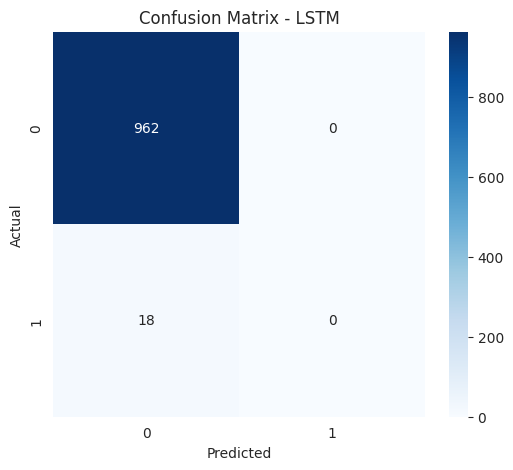

In [45]:
# Compute the confusion matrix for the LSTM model
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)

plt.figure(figsize=(6, 5)) # Set the figure size for the heatmap
# Create a heatmap of the confusion matrix
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LSTM") # Set the title of the plot
plt.xlabel("Predicted") # Set the x-axis label
plt.ylabel("Actual") # Set the y-axis label
plt.show() # Display the plot

TRAINING CURVES

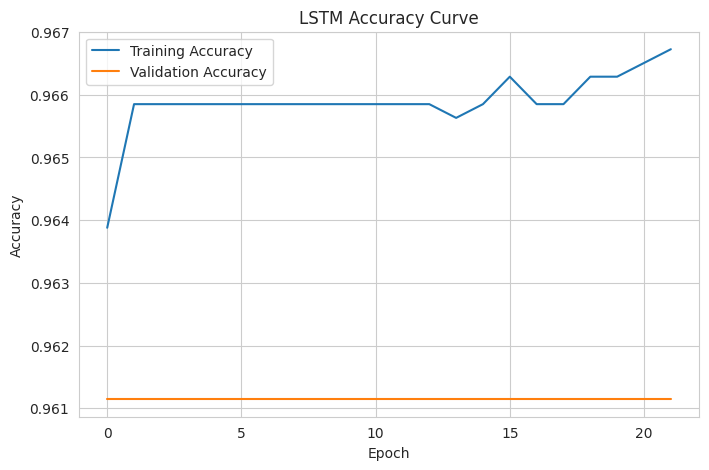

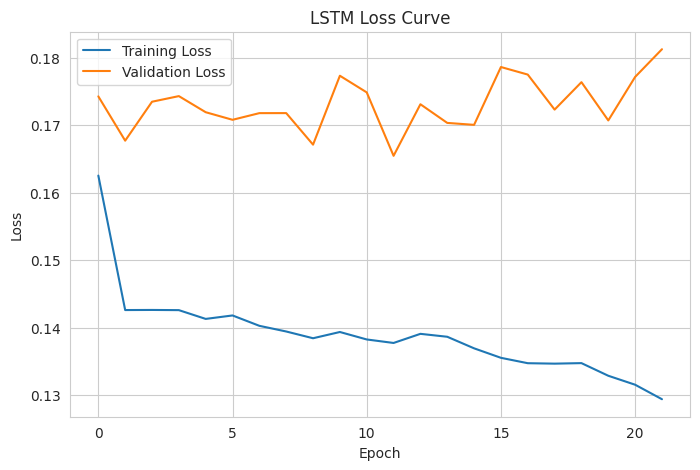

In [46]:

plt.figure(figsize=(8, 5)) # Set the figure size for the accuracy curve
# Plot training and validation accuracy over epochs
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy Curve") # Set the title
plt.xlabel("Epoch") # Set the x-axis label
plt.ylabel("Accuracy") # Set the y-axis label
plt.legend() # Display the legend
plt.show() # Display the plot

plt.figure(figsize=(8, 5)) # Set the figure size for the loss curve
# Plot training and validation loss over epochs
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss Curve") # Set the title
plt.xlabel("Epoch") # Set the x-axis label
plt.ylabel("Loss") # Set the y-axis label
plt.legend() # Display the legend
plt.show() # Display the plot

 FINAL MODEL COMPARISON

In [47]:

# Create a DataFrame to compare the final performance of all models
final_results = pd.DataFrame({
    "Model": ["Random Forest", "MLP Classifier", "LSTM"], # Model names
    "Accuracy": [rf_acc, mlp_acc, lstm_acc], # Test accuracy scores for each model
    "Weighted F1 Score": [rf_f1, mlp_f1, lstm_f1] # Test weighted F1 scores for each model
})

display(final_results.sort_values(by="Accuracy", ascending=False)) # Display the results, sorted by accuracy

,Model,Accuracy,Weighted F1 Score
2,LSTM,0.981633,0.972534
0,Random Forest,0.977099,0.972083
1,MLP Classifier,0.973282,0.968939


FINAL COMPARISON CHART

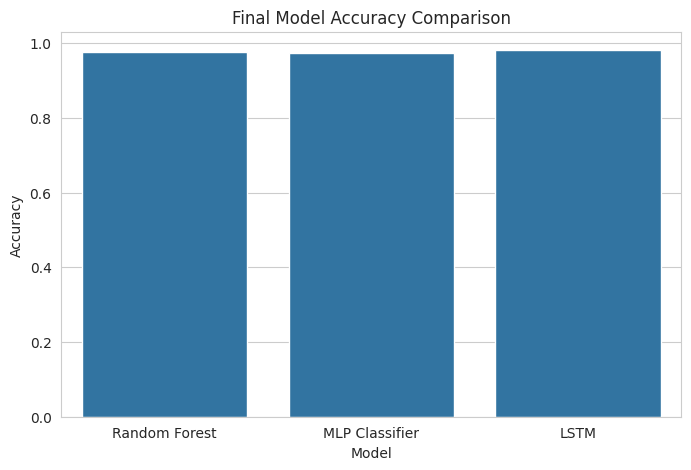

In [48]:

plt.figure(figsize=(8, 5)) # Set the figure size
# Create a bar plot comparing the accuracy of all models
sns.barplot(data=final_results, x="Model", y="Accuracy")
plt.title("Final Model Accuracy Comparison") # Set the title of the plot
plt.xlabel("Model") # Set the x-axis label
plt.ylabel("Accuracy") # Set the y-axis label
plt.show() # Display the plot

 SAVE MODELS

In [49]:

# Save traditional ML models using joblib (recommended for scikit-learn models)
joblib.dump(rf_model, "random_forest_model.pkl") # Save Random Forest model
joblib.dump(mlp_model, "mlp_classifier_model.pkl") # Save MLP Classifier model

# Save LSTM model using Keras's native save method (saves architecture, weights, and optimizer state)
lstm_model.save("lstm_classification_model.h5")

# Save training history of the LSTM model using pickle
with open("lstm_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Models and history saved successfully.")

Models and history saved successfully.
